In [1]:
"""
Created on Mon Mar 27 17:37 2023

Apply the ensemble of NN to Smith data and only take ensemble mean

Author: @claraburgard

"""

'\nCreated on Mon Mar 27 17:37 2023\n\nApply the ensemble of NN to Smith data and only take ensemble mean\n\nAuthor: @claraburgard\n\n'

In [9]:
import numpy as np
import xarray as xr
from tqdm.notebook import trange, tqdm
import glob
import matplotlib as mpl
import matplotlib.pyplot as plt
#import seaborn as sns
import datetime
import time
import os,sys
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from contextlib import redirect_stdout

import sys
sys.path.insert(1, '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt')

from nn_functions.constants import *
import nn_functions.diagnostic_functions as diag
import nn_functions.data_formatting as dfmt
import nn_functions.postprocessing_functions as pp
#from nn_functions.constants import *

DEFINE OPTIONS

In [10]:
mod_size =  'small' #'mini', 'small', 'medium', 'large', 'extra_large'
TS_opt = 'extrap' # extrap, whole, thermocline
norm_method =  'std' # std, interquart, minmax
exp_name = 'newbasic2'#'allbutconstants' #'onlyTSdraftandslope' #'TSdraftbotandiceddandwcd' #'onlyTSisfdraft' #'TSdraftbotandiceddandwcdreldGL' #TSdraftslopereldGL

In [11]:
nemo_run = 'bf663'#'bi646' #bf663
nemo_run = 'OPM018'

In [12]:
#tblock_dim = range(1980, 1980 + 60)
    #isf_dim = [2,3,4,5,6,7,8,9,10,11,12,13,17,18,20,22,23,24,25,26,29,30,31,32,33,34,35,39,40,42,
    #           43,44,45,47,49,51,55,58,59,61,62,64,65,66,69,70,71,73,74,75,78,79,84,85,90,98,99,100,104,107,108]
#isf_dim = [10,11,12,13,18,22,23,24,25,30,31,33,38,39,40,42,43,44,45,47,48,51,52,53,54,55,58,61,65,66,69,70,71,73,75]
#isf_dim = [10,11,12,13,18,22,23,25,30,31,33,39,40,42,43,44,45,47,51,55,58,61,65,66,69,70,71,73,75] # for bi646
#isf_dim = [10,11,12,13,18,22,23,25,30,31,33,39,40,42,43,44,45,47,51,55,58,61,65,66,69,70,71,73,75]

READ IN DATA

In [13]:
#inputpath_data_nn = '/bettik/burgardc/DATA/NN_PARAM/interim/INPUT_DATA/'
inputpath_data_nn = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/interim/INPUT_DATA/'

In [14]:
if TS_opt == 'extrap':
    inputpath_CVinput = inputpath_data_nn+'EXTRAPOLATED_ISFDRAFT_CHUNKS/'
    inputpath_csv = inputpath_data_nn+'SMITH_'+nemo_run+'_EXTRAPDRAFT_CHUNKS/'
elif TS_opt == 'whole':
    inputpath_CVinput = inputpath_data_nn+'WHOLE_PROF_CHUNKS_CV/'
    path_orig_data = inputpath_data_nn+'WHOLE_PROF_CHUNKS/'
elif TS_opt == 'thermocline':
    inputpath_CVinput = inputpath_data_nn+'THERMOCLINE_CHUNKS_CV/'

APPLY MODEL

In [15]:
#input_vars = ['dGL','dIF','corrected_isfdraft','bathy_metry','slope_bed_lon','slope_bed_lat','slope_ice_lon','slope_ice_lat','isfdraft_conc','theta_in','salinity_in','u_tide']
if exp_name == 'onlyTSdraft':
    input_vars = ['corrected_isfdraft','theta_in','salinity_in']
elif exp_name == 'TSdraftbotandiceddandwcd':
    input_vars = ['corrected_isfdraft','theta_in','salinity_in','water_col_depth','theta_bot','salinity_bot']
elif exp_name == 'TSdraftbotandiceddandwcdreldGL':
    input_vars = ['corrected_isfdraft','theta_in','salinity_in','water_col_depth','theta_bot','salinity_bot','rel_dGL']
elif exp_name == 'onlyTSdraftandslope':
    input_vars = ['corrected_isfdraft','theta_in','salinity_in','slope_ice_lon','slope_ice_lat']
elif exp_name == 'onlyTSdraft2':
    input_vars = ['corrected_isfdraft','theta_in','salinity_in']
elif exp_name == 'TSTfdGLdIFwcd':
    input_vars = ['corrected_isfdraft','theta_in','salinity_in','dGL','dIF','slope_ice_lon','slope_ice_lat','water_col_depth']
elif exp_name == 'TSdraftslopereldGL':
    input_vars = ['corrected_isfdraft','theta_in','salinity_in','slope_ice_lon','slope_ice_lat','rel_dGL']
elif exp_name == 'allbutconstants':
    input_vars = ['dGL','dIF','corrected_isfdraft','bathy_metry','slope_bed_lon','slope_bed_lat','slope_ice_lon','slope_ice_lat',
                'isfdraft_conc','theta_in','salinity_in','u_tide']
elif exp_name == 'newbasic':
    input_vars = ['dGL','dIF','corrected_isfdraft','bathy_metry','slope_bed_lon','slope_bed_lat','slope_ice_lon','slope_ice_lat',
                'theta_in','salinity_in']
elif exp_name == 'newbasic2':
    input_vars = ['dGL','dIF','corrected_isfdraft','bathy_metry','slope_bed_lon','slope_bed_lat','slope_ice_lon','slope_ice_lat',
                'theta_in','salinity_in','T_mean', 'S_mean', 'T_std', 'S_std']

In [16]:
#inputpath_boxes = '/bettik/burgardc/DATA/NN_PARAM/interim/BOXES/SMITH_'+nemo_run+'/'
inputpath_boxes = '/bettik/burgardc/DATA/NN_PARAM/interim/BOXES/'+nemo_run+'/'
# Required subfiles in boxes folder are
# inputpath_boxes + 'nemo_5km_boxes_2D_oneFRIS_'+str(tt)+'_merged75.nc'
# inputpath_boxes + 'nemo_5km_boxes_1D_oneFRIS_'+str(tt)+'_merged75.nc'

#inputpath_mask='/bettik/burgardc/DATA/NN_PARAM/interim/ANTARCTICA_IS_MASKS/SMITH_'+nemo_run+'/'
inputpath_mask='/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/interim/ANTARCTICA_IS_MASKS/nemo_5km_'+nemo_run+'/'

#inputpath_data='/bettik/burgardc/DATA/NN_PARAM/interim/SMITH_'+nemo_run+'/'
inputpath_data='/bettik/burgardc/DATA/NN_PARAM/interim/nemo_5km_'+nemo_run+'/'
inputpath_data='/bettik/burgardc/DATA/BASAL_MELT_PARAM/interim/NEMO_eORCA025.L121_'+nemo_run+'_ANT_STEREO/'
# Required subfiles in data folder are
# inputpath_data+'other_mask_vars_Ant_stereo.nc'
# inputpath_data+'corrected_draft_bathy_isf.nc'
# inputpath_data+'isfdraft_conc_Ant_stereo.nc'
# But I think these are actually all things needed for the Smith data and not for my purposes?

### use any model from CV over time
#outputpath_melt_nn = '/bettik/burgardc/DATA/NN_PARAM/processed/MELT_RATE/SMITH_'+nemo_run+'/'
outputpath_melt_nn = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/processed/MELT_RATE/nemo_5km_'+nemo_run+'/'
#path_model = '/bettik/burgardc/DATA/NN_PARAM/interim/NN_MODELS/experiments/WHOLE/'
path_model = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/interim/NN_MODELS/'

In [17]:
glob.glob(inputpath_mask+'*.nc')

['/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/interim/ANTARCTICA_IS_MASKS/nemo_5km_OPM018/outfile.nc',
 '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/interim/ANTARCTICA_IS_MASKS/nemo_5km_OPM018/BedMachinev2_4km_isf_masks_and_info_and_distance_oneFRIS.nc',
 '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/interim/ANTARCTICA_IS_MASKS/nemo_5km_OPM018/mask_ground.nc',
 '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/interim/ANTARCTICA_IS_MASKS/nemo_5km_OPM018/preliminary_mask_file.nc',
 '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/interim/ANTARCTICA_IS_MASKS/nemo_5km_OPM018/nemo_5km_slope_info_bedrock_draft_latlon_oneFRIS.nc',
 '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/interim/ANTARCTICA_IS_MASKS/nemo_5km_OPM018/nemo_5km_isf_masks_and_info_and_distance_new_oneFRIS.nc',
 '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/interim/ANTARCTICA_IS_MASKS/nemo_5km_OPM018/mask_pin_lines.nc',
 '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/interim/ANTARCTICA_IS_MAS

In [18]:
# This is the code that does the same thing as the function read_input_evalmetrics_NN_yy, but for just one block
# It is supposed to just read in one time as well I think 

#file_isf_orig = xr.open_dataset(inputpath_mask+'nemo_5km_isf_masks_and_info_and_distance_new_oneFRIS.nc')#.drop('time')
file_isf_orig = xr.open_dataset(inputpath_mask+'BedMachinev2_4km_isf_masks_and_info_and_distance_oneFRIS.nc')
#file_isf = file_isf_orig.sel(Nisf=isf_list)
nonnan_Nisf = file_isf_orig['Nisf'].where(np.isfinite(file_isf_orig['front_bot_depth_max']), drop=True).astype(int)
file_isf_nonnan = file_isf_orig.sel(Nisf=nonnan_Nisf)
large_isf = file_isf_nonnan['Nisf'].where(file_isf_nonnan['isf_area_here'] >= 2500, drop=True)
file_isf = file_isf_nonnan.sel(Nisf=large_isf)
if 'labels' in file_isf.coords.keys():
    file_isf = file_isf.drop('labels')


map_lim = [-3000000,3000000]
file_mask_orig = xr.open_dataset(inputpath_data+'other_mask_vars_Ant_stereo.nc')
file_mask_orig_cut = dfmt.cut_domain_stereo(file_mask_orig, map_lim, map_lim)
#file_mask_orig_cut = file_mask_orig_cut.assign_coords({'time': range(1970, 1970 + len(file_mask_orig_cut.time))}).sel(time=tt).drop('time')

file_other = xr.open_dataset(inputpath_data+'corrected_draft_bathy_isf.nc')#, chunks={'x': chunk_size, 'y': chunk_size})
file_other_cut = dfmt.cut_domain_stereo(file_other, map_lim, map_lim)
#file_other_cut = file_other_cut.assign_coords({'time': range(1970, 1970 + len(file_other_cut.time))}).sel(time=tt).drop('time')

file_conc = xr.open_dataset(inputpath_data+'isfdraft_conc_Ant_stereo.nc')
file_conc_cut = dfmt.cut_domain_stereo(file_conc, map_lim, map_lim)
#file_conc_cut = file_conc_cut.assign_coords({'time': range(1970, 1970 + len(file_conc_cut.time))}).sel(time=tt).drop('time')

ice_draft_pos = file_other_cut['corrected_isfdraft']
ice_draft_neg = -ice_draft_pos

#box_charac_2D = xr.open_dataset(inputpath_boxes + 'nemo_5km_boxes_2D_oneFRIS_'+str(tt)+'_merged75.nc')
#box_charac_1D = xr.open_dataset(inputpath_boxes + 'nemo_5km_boxes_1D_oneFRIS_'+str(tt)+'_merged75.nc')

isf_stack_mask = dfmt.create_stacked_mask(file_isf['ISF_mask'], file_isf.Nisf, ['y','x'], 'mask_coord')

file_isf_conc = file_conc_cut['isfdraft_conc']

xx = file_isf.x
yy = file_isf.y
dx = (xx[2] - xx[1]).values
dy = (yy[2] - yy[1]).values
grid_cell_area = abs(dx*dy)  
grid_cell_area_weighted = file_isf_conc * grid_cell_area

geometry_info_2D = xr.merge([ice_draft_pos.rename('ice_draft_pos'),
                        grid_cell_area_weighted.rename('grid_cell_area_weighted'),
                        file_isf_conc])

In [19]:
# At this point, we expect to have the following files
# return file_isf, geometry_info_2D, box_charac_2D, box_charac_1D, isf_stack_mask
# We do have these ones
# file_isf, geometry_info_2D, isf_stack_mask
# We don't actually have these ones anymore because we ignored the box parameterisation
# box_charac_2D, box_charac_1D 

In [20]:
# Then we move on to preparing the data to apply the NN
res_1D_list = []
res_2D_all = None
norm_metrics_file = xr.open_dataset(inputpath_CVinput + 'metrics_norm_wholedataset.nc')
norm_metrics = norm_metrics_file.sel(norm_method=norm_method).drop('norm_method').to_dataframe()
df_nrun = pd.read_csv(inputpath_CVinput + 'dataframe_input_isf.csv',index_col=[0,1])
#geometry_isf_2D = dfmt.choose_isf(geometry_info_2D,isf_stack_mask, kisf)
#box_loc_config_stacked = dfmt.choose_isf(box1, isf_stack_mask, kisf)
                

In [21]:
# Specify just one time (so that there are no problems with repeat coordinates) 
df_nrun = df_nrun[df_nrun['time'] == 2008]

In [23]:
ens_res2D_list = []
seed_nb = 10
model = keras.models.load_model(path_model + 'model_nn_'+mod_size+'_'+exp_name+\
                                '_wholedataset_'+str(seed_nb).zfill(2)+'_TS'+TS_opt+'_norm'+norm_method+'.keras')

ValueError: File not found: filepath=/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/interim/NN_MODELS/model_nn_small_newbasic2_wholedataset_10_TSextrap_normstd.keras. Please ensure the file is an accessible `.keras` zip file.

In [7]:
# At this point, we switch to the function apply_NN_results_2D_1isf_1tblock
# res_2D = pp.apply_NN_results_2D_1isf_1tblock(file_isf, norm_metrics, df_nrun, model, input_vars)
def apply_NN_results_2D_1isf_1tblock(file_isf, norm_metrics, df_nrun, model, input_vars=[]):
    """
    Compute 2D melt based on a given NN model
    
    """

    val_norm = normalise_vars(df_nrun,
                                norm_metrics.loc['mean_vars'],
                                norm_metrics.loc['range_vars'])

    x_val_norm = val_norm[input_vars]
    y_val_norm = val_norm['melt_m_ice_per_y']

    y_out_norm = model.predict(x_val_norm.values,verbose = 0)

    y_out_norm_xr = xr.DataArray(data=y_out_norm.squeeze()).rename({'dim_0': 'index'})
    y_out_norm_xr = y_out_norm_xr.assign_coords({'index': x_val_norm.index})

    # denormalise the output
    y_out = denormalise_vars(y_out_norm_xr, 
                             norm_metrics['melt_m_ice_per_y'].loc['mean_vars'],
                             norm_metrics['melt_m_ice_per_y'].loc['range_vars'])

    y_out_pd_s = pd.Series(y_out.values,index=df_nrun.index,name='predicted_melt') 
    y_target_pd_s = pd.Series(df_nrun['melt_m_ice_per_y'].values,index=df_nrun.index,name='reference_melt') 

    # put some order in the file
    y_out_xr = y_out_pd_s.to_xarray()
    y_target_xr = y_target_pd_s.to_xarray()
    y_to_compare = xr.merge([y_out_xr, y_target_xr]).sortby('y')

    y_whole_grid = y_to_compare.reindex_like(file_isf['ISF_mask'])
    return y_whole_grid        

In [25]:
val_norm = pp.normalise_vars(df_nrun,
                            norm_metrics.loc['mean_vars'],
                            norm_metrics.loc['range_vars'])

x_val_norm = val_norm[input_vars]
y_val_norm = val_norm['melt_m_ice_per_y']

In [26]:
x_val_norm

dGL  dIF  corrected_isfdraft  bathy_metry  \
y          x                                                       
-2132000.0  1052000.0  NaN  NaN                 NaN          NaN   
            1057000.0  NaN  NaN                 NaN          NaN   
            1062000.0  NaN  NaN                 NaN          NaN   
            1077000.0  NaN  NaN                 NaN          NaN   
            1082000.0  NaN  NaN                 NaN          NaN   
...                    ...  ...                 ...          ...   
 2238000.0 -13000.0    NaN  NaN                 NaN          NaN   
           -8000.0     NaN  NaN                 NaN          NaN   
           -3000.0     NaN  NaN                 NaN          NaN   
            2000.0     NaN  NaN                 NaN          NaN   
            7000.0     NaN  NaN                 NaN          NaN   

                       slope_bed_lon  slope_bed_lat  slope_ice_lon  \
y          x                                                         
-2132000.0  1052000.0            NaN            NaN            NaN   
            1057000.0            NaN            NaN            NaN   
            1062000.0            NaN            NaN            NaN   
            1077000.0            NaN            NaN            NaN   
            1082000.0            NaN            NaN            NaN   
...                              ...            ...            ...   
 2238000.0 -13000.0              NaN            NaN            NaN   
           -8000.0               NaN            NaN            NaN   
           -3000.0               NaN            NaN            NaN   
            2000.0               NaN            NaN            NaN   
            7000.0               NaN            NaN            NaN   

                       slope_ice_lat  theta_in  salinity_in  T_mean  S_mean  \
y          x                                                                  
-2132000.0  1052000.0            NaN       NaN          NaN     NaN     NaN   
            1057000.0            NaN       NaN          NaN     NaN     NaN   
            1062000.0            NaN       NaN          NaN     NaN     NaN   
            1077000.0            NaN       NaN          NaN     NaN     NaN   
            1082000.0            NaN       NaN          NaN     NaN     NaN   
...                              ...       ...          ...     ...     ...   
 2238000.0 -13000.0              NaN       NaN          NaN     NaN     NaN   
           -8000.0               NaN       NaN          NaN     NaN     NaN   
           -3000.0               NaN       NaN          NaN     NaN     NaN   
            2000.0               NaN       NaN          NaN     NaN     NaN   
            7000.0               NaN       NaN          NaN     NaN     NaN   

                       T_std  S_std  
y          x                         
-2132000.0  1052000.0    NaN    NaN  
            1057000.0    NaN    NaN  
            1062000.0    NaN    NaN  
            1077000.0    NaN    NaN  
            1082000.0    NaN    NaN  
...                      ...    ...  
 2238000.0 -13000.0      NaN    NaN  
           -8000.0       NaN    NaN  
           -3000.0       NaN    NaN  
            2000.0       NaN    NaN  
            7000.0       NaN    NaN  

[64116 rows x 14 columns]

In [24]:
y_out_norm = model.predict(x_val_norm.values,verbose = 0)

y_out_norm_xr = xr.DataArray(data=y_out_norm.squeeze()).rename({'dim_0': 'index'})
y_out_norm_xr = y_out_norm_xr.assign_coords({'index': x_val_norm.index})

# denormalise the output
y_out = pp.denormalise_vars(y_out_norm_xr, 
                         norm_metrics['melt_m_ice_per_y'].loc['mean_vars'],
                         norm_metrics['melt_m_ice_per_y'].loc['range_vars'])

y_out_pd_s = pd.Series(y_out.values,index=df_nrun.index,name='predicted_melt') 
y_target_pd_s = pd.Series(df_nrun['melt_m_ice_per_y'].values,index=df_nrun.index,name='reference_melt') 

y_out_xr = y_out_pd_s.to_xarray()
y_target_xr = y_target_pd_s.to_xarray()
y_to_compare = xr.merge([y_out_xr, y_target_xr]).sortby('y')

y_whole_grid = y_to_compare.reindex_like(file_isf['ISF_mask'])
res_2D = y_whole_grid

NameError: name 'model' is not defined

In [177]:
res_2D['reference_melt']

<xarray.DataArray 'reference_melt' (y: 1200, x: 1200)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * y        (y) float64 2.998e+06 2.993e+06 2.988e+06 ... -2.992e+06 -2.997e+06
  * x        (x) float64 -2.998e+06 -2.993e+06 ... 2.992e+06 2.997e+06

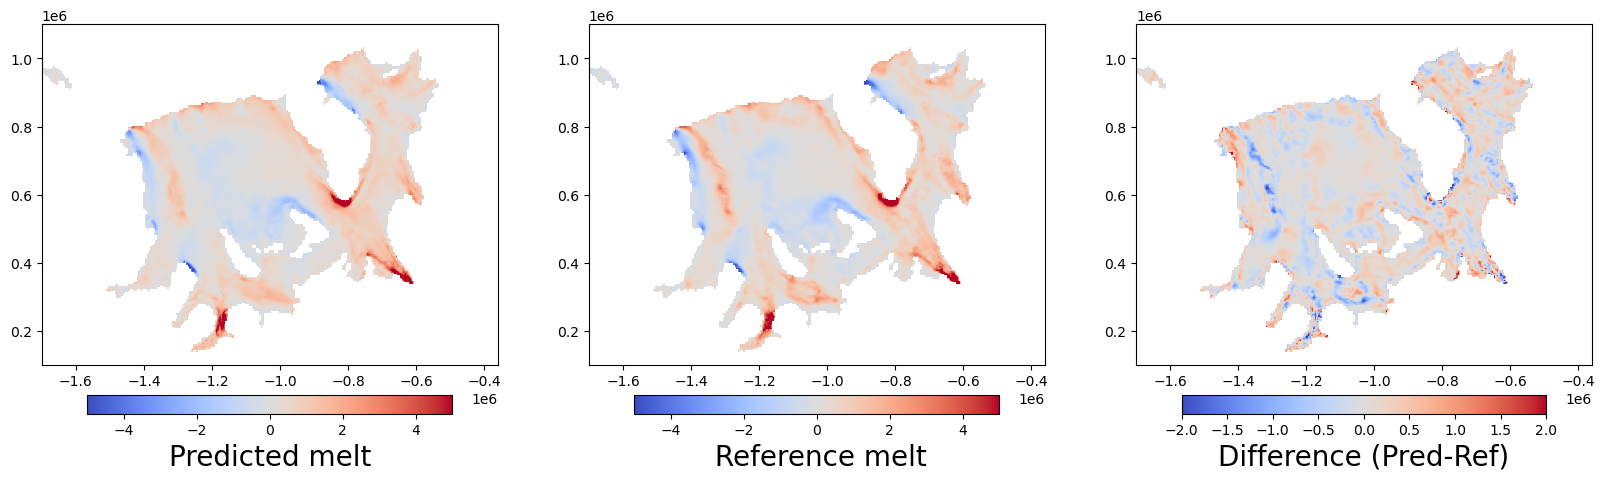

In [178]:
# At this point we should have res_2D
fig, ax = plt.subplots(1,3, figsize = (20,8))
bounds = [np.min(geometry_info_2D.x), np.max(geometry_info_2D.x), np.min(geometry_info_2D.y), np.max(geometry_info_2D.y)]
im = [[],[],[]]
titles = ['Predicted melt',' Reference melt', 'Difference (Pred-Ref)']
im[0] = ax[0].imshow(res_2D.predicted_melt, cmap = 'coolwarm', extent = bounds)
im[1] = ax[1].imshow(res_2D.reference_melt, cmap = 'coolwarm', extent = bounds)
im[2] = ax[2].imshow(res_2D.predicted_melt - res_2D.reference_melt, cmap = 'coolwarm', extent = bounds)
for i in range(3):
    cb = plt.colorbar(im[i], ax = ax[i], orientation='horizontal', shrink = 0.8, pad = 0.05)
    cb.set_label(titles[i], fontsize = 20)
    ax[i].set_xlim(-1.7e6,-0.36e6)
    ax[i].set_ylim(0.1e6,1.1e6)
    #ax[i].set_title(titles[i], fontsize = 20)
im[0].set_clim(-5,5)
im[1].set_clim(-5,5)
im[2].set_clim(-2,2)

In [179]:
ens_res2D_list.append(res_2D.assign_coords({'seed_nb': seed_nb}))
xr_ens_res2D = xr.concat(ens_res2D_list, dim='seed_nb')
xr_ensstd_res2D = xr_ens_res2D['predicted_melt'].std('seed_nb')

In [180]:
xr_ens_res2D, xr_ensstd_res2D

(<xarray.Dataset>
 Dimensions:         (y: 1200, x: 1200, seed_nb: 1)
 Coordinates:
   * y               (y) float64 2.998e+06 2.993e+06 ... -2.992e+06 -2.997e+06
   * x               (x) float64 -2.998e+06 -2.993e+06 ... 2.992e+06 2.997e+06
   * seed_nb         (seed_nb) int64 10
 Data variables:
     predicted_melt  (seed_nb, y, x) float32 nan nan nan nan ... nan nan nan nan
     reference_melt  (seed_nb, y, x) float64 nan nan nan nan ... nan nan nan nan,
 <xarray.DataArray 'predicted_melt' (y: 1200, x: 1200)>
 array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
 Coordinates:
   * y        (y) float64 2.998e+06 2.993e+06 2.988e+06 ... -2.992e+06 -2.997e+06
   * x        (x) float64 -2.998e+06 -2.993e+06 ... 2.992e+06 2.997e+06)

In [181]:
# Next we want to melt_rate_2D_isf_m_per_y = dfmt.choose_isf(xr_ens_res2D['predicted_melt'],isf_stack_mask, kisf)
def choose_isf(var, isf_stacked_mask, kisf):
    # choose a given ice shelf based on stacked coordinate
    return var.stack(mask_coord=['y','x']).sel(mask_coord=isf_stacked_mask.sel(Nisf=kisf).dropna('mask_coord'))

In [182]:
res_1D_list = []
res_2D_all = None
for kisf in file_isf.Nisf.values: 
    geometry_isf_2D = dfmt.choose_isf(geometry_info_2D,isf_stack_mask, kisf)
    #box_loc_config_stacked = dfmt.choose_isf(box1, isf_stack_mask, kisf)
    melt_rate_2D_isf_m_per_y = dfmt.choose_isf(xr_ens_res2D['predicted_melt'],isf_stack_mask, kisf)
    melt_rate_1D_isf_Gt_per_y = (melt_rate_2D_isf_m_per_y * geometry_isf_2D['grid_cell_area_weighted']).sum(dim=['mask_coord']) * rho_i / 10**12
    #param_melt_2D_box1_isf = melt_rate_2D_isf_m_per_y.where(np.isfinite(box_loc_config_stacked))
    #melt_rate_1D_isf_myr_box1_mean = dfmt.weighted_mean(param_melt_2D_box1_isf,['mask_coord'], geometry_isf_2D['isfdraft_conc'])     
    print(melt_rate_1D_isf_Gt_per_y[0].Nisf.data, '{:.2f}'.format(melt_rate_1D_isf_Gt_per_y[0].data))
    #print(melt_rate_1D_isf_Gt_per_y[0].seed_nb.data)
    #out_1D = xr.concat([melt_rate_1D_isf_Gt_per_y, melt_rate_1D_isf_myr_box1_mean], dim='metrics').assign_coords({'metrics': ['Gt','box1']})
    out_1D = xr.concat([melt_rate_1D_isf_Gt_per_y], dim='metrics').assign_coords({'metrics': ['Gt']})

    res_1D_list.append(out_1D)

2 28.57
5 3.13
7 4.11
8 21.24
9 19.12
11 7.14
21 66.08
24 17.14
26 15.03
27 1.20
33 28.39
34 7.35
47 4.46
66 74.20
75 57.14
77 12.11
82 110.38
83 70.33
84 39.25
85 29.45
86 40.53
88 3.60
90 19.83
92 5.08
98 3.15
99 14.50
101 0.81
109 6.49
117 19.90
118 1.94
124 129.22
127 13.11
128 15.35
132 2.97
134 4.26


In [183]:
res_1D_all = xr.concat(res_1D_list, dim='Nisf')

In [184]:
if res_2D_all is None:
    res_2D_all = xr_ensstd_res2D
else:
    res_2D_all = res_2D_all.combine_first(xr_ensstd_res2D)

res_2D_all.to_netcdf(outputpath_melt_nn + 'evalmetrics_2D_'+mod_size+'_'+exp_name+'_ensstd_'+TS_opt+'_norm'+norm_method+'_'+nemo_run+'.nc')
res_1D_all.to_dataset(name='predicted_melt').to_netcdf(outputpath_melt_nn + 'evalmetrics_1D_'+mod_size+'_'+exp_name+'_allmembers_'+TS_opt+'_norm'+norm_method+'_'+nemo_run+'.nc')


In [185]:
res_2D_all, xr_ensstd_res2D

(<xarray.DataArray 'predicted_melt' (y: 1200, x: 1200)>
 array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
 Coordinates:
   * y        (y) float64 2.998e+06 2.993e+06 2.988e+06 ... -2.992e+06 -2.997e+06
   * x        (x) float64 -2.998e+06 -2.993e+06 ... 2.992e+06 2.997e+06,
 <xarray.DataArray 'predicted_melt' (y: 1200, x: 1200)>
 array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
 Coordinates:
   * y        (y) float64 2.998e+06 2.993e+06 2.988e+06 ... -2.992e+06 -2.997e+06
   * x        (x) float64

In [ ]:
# This is the function to do this for multiple different blocks (but initially I am only doing this for one block)
def read_input_evalmetrics_NN_yy(nemo_run, tt, in_boxes, in_data, in_mask):    
    
    file_isf_orig = xr.open_dataset(inputpath_mask+'nemo_5km_isf_masks_and_info_and_distance_oneFRIS_'+str(tt)+'.nc').drop('time')
    #file_isf = file_isf_orig.sel(Nisf=isf_list)
    nonnan_Nisf = file_isf_orig['Nisf'].where(np.isfinite(file_isf_orig['front_bot_depth_max']), drop=True).astype(int)
    file_isf_nonnan = file_isf_orig.sel(Nisf=nonnan_Nisf)
    large_isf = file_isf_nonnan['Nisf'].where(file_isf_nonnan['isf_area_here'] >= 2500, drop=True)
    file_isf = file_isf_nonnan.sel(Nisf=large_isf)
    if 'labels' in file_isf.coords.keys():
        file_isf = file_isf.drop('labels')
    
    
    map_lim = [-3000000,3000000]
    file_mask_orig = xr.open_dataset(inputpath_data+'other_mask_vars_Ant_stereo.nc')
    file_mask_orig_cut = dfmt.cut_domain_stereo(file_mask_orig, map_lim, map_lim)
    #file_mask_orig_cut = file_mask_orig_cut.assign_coords({'time': range(1970, 1970 + len(file_mask_orig_cut.time))}).sel(time=tt).drop('time')

    file_other = xr.open_dataset(inputpath_data+'corrected_draft_bathy_isf.nc')#, chunks={'x': chunk_size, 'y': chunk_size})
    file_other_cut = dfmt.cut_domain_stereo(file_other, map_lim, map_lim)
    #file_other_cut = file_other_cut.assign_coords({'time': range(1970, 1970 + len(file_other_cut.time))}).sel(time=tt).drop('time')

    file_conc = xr.open_dataset(inputpath_data+'isfdraft_conc_Ant_stereo.nc')
    file_conc_cut = dfmt.cut_domain_stereo(file_conc, map_lim, map_lim)
    #file_conc_cut = file_conc_cut.assign_coords({'time': range(1970, 1970 + len(file_conc_cut.time))}).sel(time=tt).drop('time')
    
    ice_draft_pos = file_other_cut['corrected_isfdraft'].sel(time=tt)
    ice_draft_neg = -ice_draft_pos
    
    box_charac_2D = xr.open_dataset(inputpath_boxes + 'nemo_5km_boxes_2D_oneFRIS_'+str(tt)+'_merged75.nc')
    box_charac_1D = xr.open_dataset(inputpath_boxes + 'nemo_5km_boxes_1D_oneFRIS_'+str(tt)+'_merged75.nc')
    
    isf_stack_mask = dfmt.create_stacked_mask(file_isf['ISF_mask'], file_isf.Nisf, ['y','x'], 'mask_coord')

    file_isf_conc = file_conc_cut['isfdraft_conc'].sel(time=tt)

    xx = file_isf.x
    yy = file_isf.y
    dx = (xx[2] - xx[1]).values
    dy = (yy[2] - yy[1]).values
    grid_cell_area = abs(dx*dy)  
    grid_cell_area_weighted = file_isf_conc * grid_cell_area
    
    geometry_info_2D = xr.merge([ice_draft_pos.rename('ice_draft_pos'),
                            grid_cell_area_weighted.rename('grid_cell_area_weighted'),
                            file_isf_conc])
    
    return file_isf, geometry_info_2D, box_charac_2D, box_charac_1D, isf_stack_mask

COMPUTE ENSSTD AND INTEGRATED METRICS FOR ALL ENSEMBLES

In [ ]:
### use any model from CV over time
#outputpath_melt_nn = '/bettik/burgardc/DATA/NN_PARAM/processed/MELT_RATE/SMITH_'+nemo_run+'/'
#path_model = '/bettik/burgardc/DATA/NN_PARAM/interim/NN_MODELS/experiments/WHOLE/'

for tt in tqdm(tblock_dim):
#for tt in tqdm(range(1980,1980 + 1)):
    
    file_isf, geometry_info_2D, box_charac_2D, box_charac_1D, isf_stack_mask = read_input_evalmetrics_NN_yy(nemo_run, tt)
    
    if box_charac_2D and box_charac_1D:
        box_loc_config2 = box_charac_2D['box_location'].sel(box_nb_tot=box_charac_1D['nD_config'].sel(config=2))
        box1 = box_loc_config2.where(box_loc_config2==1).isel(Nisf=1).drop('Nisf')
    
    res_1D_list = []
    res_2D_all = None
    for kisf in file_isf.Nisf.values: 

        norm_metrics_file = xr.open_dataset(inputpath_CVinput + 'metrics_norm_wholedataset.nc')
        #norm_metrics_file_addvar1 = xr.open_dataset(inputpath_CVinput + 'metrics_norm_addvar1_CV_noisf'+str(isf_out).zfill(3)+'_notblock'+str(tblock_out).zfill(3)+'.nc')
        #norm_metrics_file_addvar1 = norm_metrics_file_addvar1.drop('salinity_in')
        #norm_metrics_file = xr.merge([norm_metrics_file_orig,norm_metrics_file_addvar1])
        norm_metrics = norm_metrics_file.sel(norm_method=norm_method).drop('norm_method').to_dataframe()

        df_nrun = pd.read_csv(inputpath_csv + 'dataframe_input_isf'+str(kisf).zfill(3)+'_'+str(tt)+'_'+nemo_run+'.csv',index_col=[0,1])
        #df_nrun_addvar1 = pd.read_csv(path_orig_data + 'dataframe_addvar1_isf'+str(kisf).zfill(3)+'_'+str(tblock_out).zfill(3)+'.csv',index_col=[0,1,2])
        #df_nrun_addvar1 = df_nrun_addvar1.drop(['salinity_in'], axis=1)
        #df_nrun = pd.concat([df_nrun_orig,df_nrun_addvar1],join = 'outer', axis = 1)

        geometry_isf_2D = dfmt.choose_isf(geometry_info_2D,isf_stack_mask, kisf)
        box_loc_config_stacked = dfmt.choose_isf(box1, isf_stack_mask, kisf)
        
        ens_res2D_list = []
        for seed_nb in range(1,11):
            model = keras.models.load_model(path_model + 'model_nn_'+mod_size+'_'+exp_name+'_wholedataset_'+str(seed_nb).zfill(2)+'_TS'+TS_opt+'_norm'+norm_method+'.h5')

            res_2D = pp.apply_NN_results_2D_1isf_1tblock(file_isf, norm_metrics, df_nrun, model, input_vars)
        
            ens_res2D_list.append(res_2D.assign_coords({'seed_nb': seed_nb}))
        
        xr_ens_res2D = xr.concat(ens_res2D_list, dim='seed_nb')
        xr_ensstd_res2D = xr_ens_res2D['predicted_melt'].std('seed_nb')

        melt_rate_2D_isf_m_per_y = dfmt.choose_isf(xr_ens_res2D['predicted_melt'],isf_stack_mask, kisf)
        melt_rate_1D_isf_Gt_per_y = (melt_rate_2D_isf_m_per_y * geometry_isf_2D['grid_cell_area_weighted']).sum(dim=['mask_coord']) * rho_i / 10**12
        param_melt_2D_box1_isf = melt_rate_2D_isf_m_per_y.where(np.isfinite(box_loc_config_stacked))
        melt_rate_1D_isf_myr_box1_mean = dfmt.weighted_mean(param_melt_2D_box1_isf,['mask_coord'], geometry_isf_2D['isfdraft_conc'])     

        out_1D = xr.concat([melt_rate_1D_isf_Gt_per_y, melt_rate_1D_isf_myr_box1_mean], dim='metrics').assign_coords({'metrics': ['Gt','box1']})

        res_1D_list.append(out_1D)
        
        if res_2D_all is None:
            res_2D_all = xr_ensstd_res2D
        else:
            res_2D_all = res_2D_all.combine_first(xr_ensstd_res2D)

    res_1D_all = xr.concat(res_1D_list, dim='Nisf')
    
    res_2D_all.to_netcdf(outputpath_melt_nn + 'evalmetrics_2D_'+mod_size+'_'+exp_name+'_ensstd_'+TS_opt+'_norm'+norm_method+'_'+str(tt)+'_'+nemo_run+'.nc')
    res_1D_all.to_dataset(name='predicted_melt').to_netcdf(outputpath_melt_nn + 'evalmetrics_1D_'+mod_size+'_'+exp_name+'_allmembers_'+TS_opt+'_norm'+norm_method+'_'+str(tt)+'_'+nemo_run+'.nc')

#    if (tblock_out == max(tblock_dim)):
#        print('I AM SAVING RESULTS FOR NEMO RUN '+nemo_run_old)
#        res_all_CV = xr.concat(res_all_list, dim='time')
#        res_all_CV.to_netcdf(outputpath_melt_nn + 'evalmetrics_2D_CV_'+mod_size+'_'+exp_name+'_'+TS_opt+'_norm'+norm_method+'_'+nemo_run_old+'.nc')

In [ ]:
    res_2D_all.to_netcdf(outputpath_melt_nn + 'evalmetrics_2D_'+mod_size+'_'+exp_name+'_ensstd_'+TS_opt+'_norm'+norm_method+'_'+str(tt)+'_'+nemo_run+'.nc')


In [140]:
(res_2D_all['predicted_melt'] - res_2D_all['reference_melt']).plot(cmap=mpl.cm.coolwarm)

NameError: name 'rxr_ens_res2D' is not defined

In [ ]:
res_2D_all['reference_melt'].where(file_isf['ISF_mask'] == 66, drop=True).plot(vmax=1)